In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Landau damping

In [2]:
closures = [
    "Gram",
    "ExtGram",
    "Grad"
]
T_end = 25.0
M_vec = [4, 6, 8, 10, 12, 14, 24]

x_lower = 0.0; x_upper = 12.566370614359172
base_tree_level = 6
polydeg = 3

epsilon = 0.01
k = 0.5

### Even Degree

M=4, k=0.5


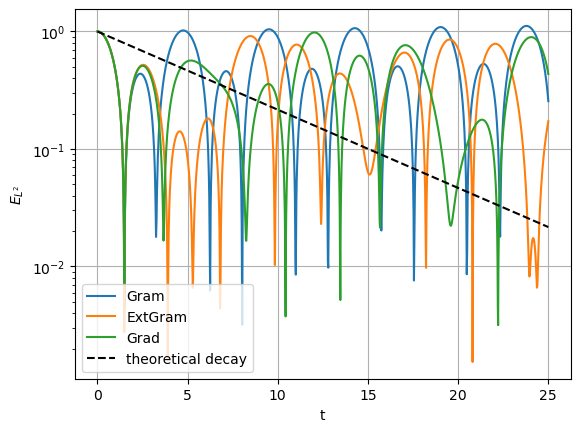

M=6, k=0.5


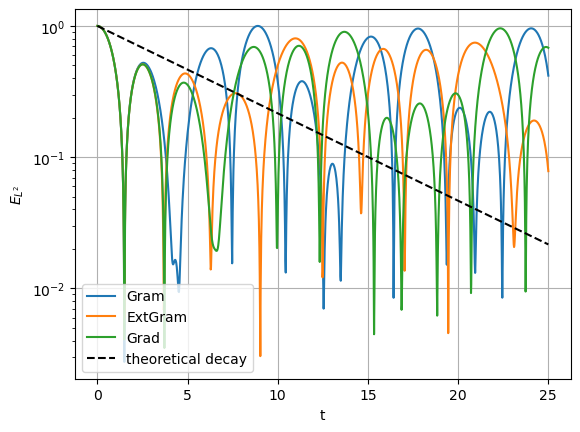

M=8, k=0.5


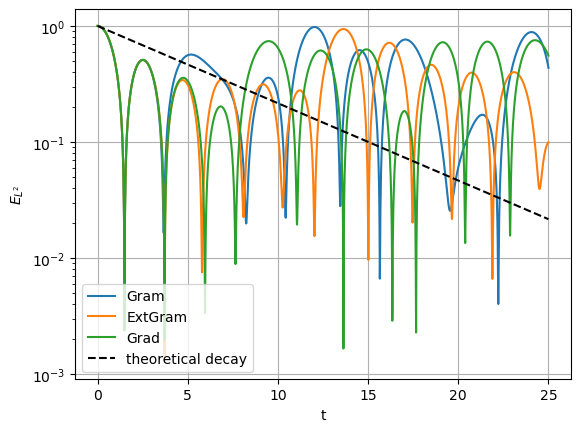

M=10, k=0.5


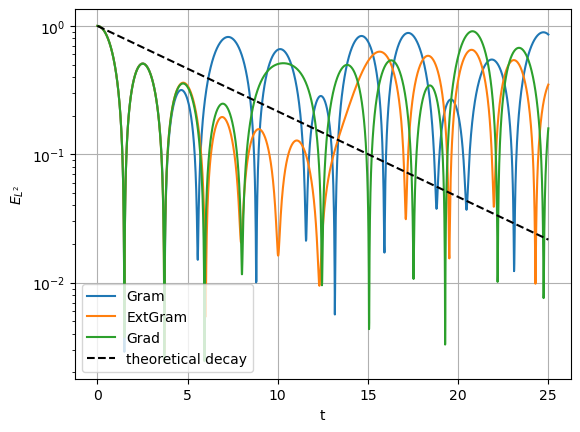

M=12, k=0.5


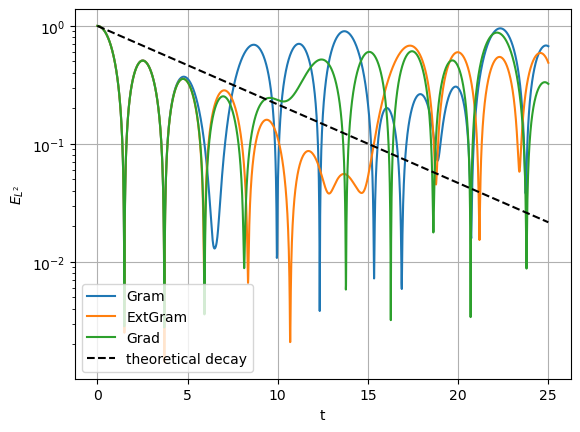

M=14, k=0.5


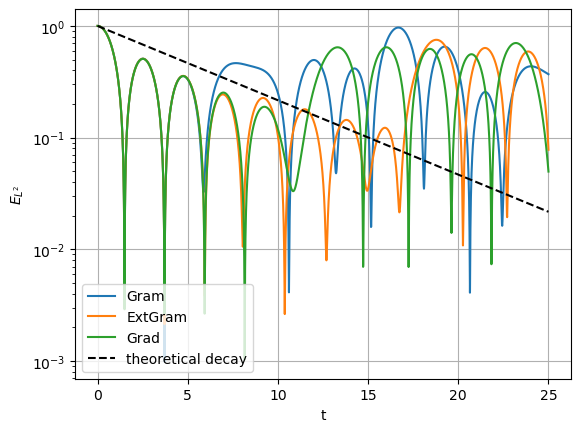

M=24, k=0.5


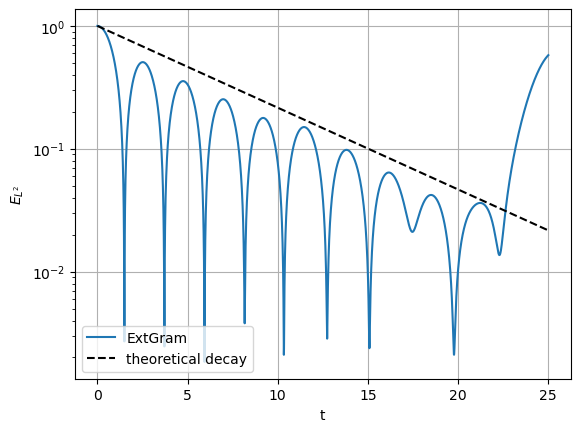

In [3]:
gamma = -0.1533
for M in M_vec:
    print(f"M={M}, k={k}")

    plt.figure()
    for closure in closures:
        if M == 24 and closure in ["Gram", "Grad"]:
            continue
        file = f"../out/VlasovPoisson/LandauDamping/energy_moments_closure{closure}_T{T_end}_M{M}_k{k}_ϵ{epsilon}_p{polydeg}_level{base_tree_level}_x_lower{x_lower}_x_upper{x_upper}.csv"
        data = pd.read_csv(file)

        plt.plot(data["time"], data["E_L2"] / data["E_L2"][0], label=closure)

    plt.plot(data["time"], np.exp(gamma * data["time"]), 'k--', label="theoretical decay")
    plt.yscale("log")
    plt.xlabel("t")
    plt.ylabel("$E_{L^2}$")
    plt.legend(loc='lower left')
    plt.grid()
    plt.savefig(f"../out/VlasovPoisson/LandauDamping/LandauDamping_M{M}_k{k}_epsilon{epsilon}_p{polydeg}.pdf")
    plt.show()

### Odd Degree

M=5, k=0.5


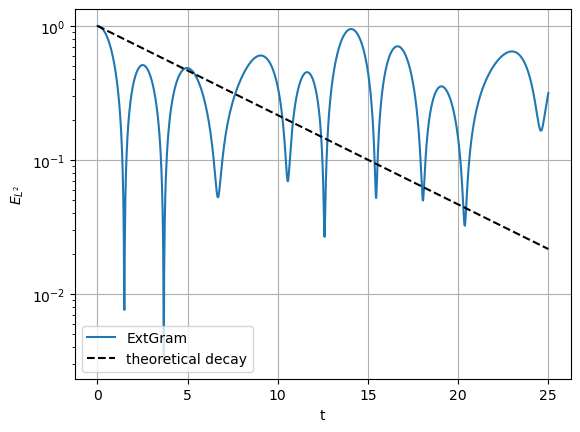

M=7, k=0.5


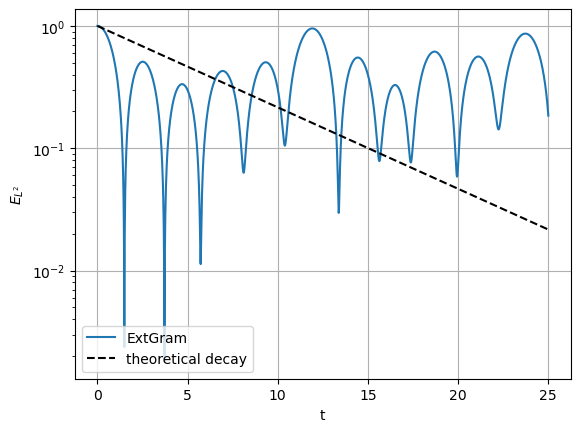

M=9, k=0.5


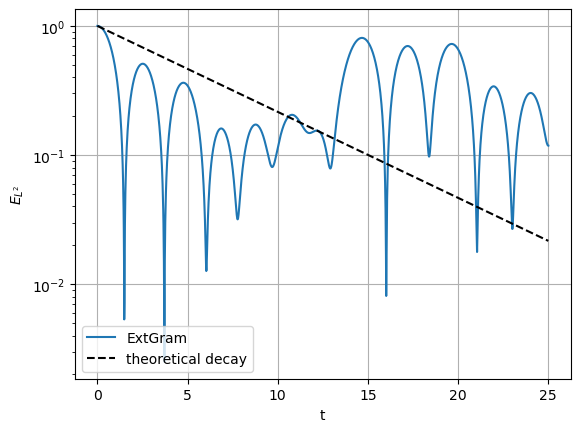

M=11, k=0.5


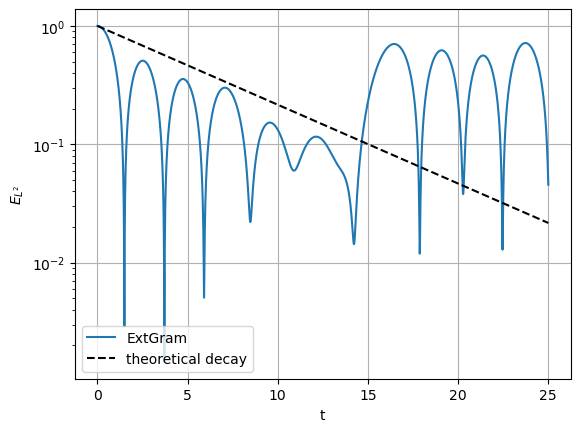

M=13, k=0.5


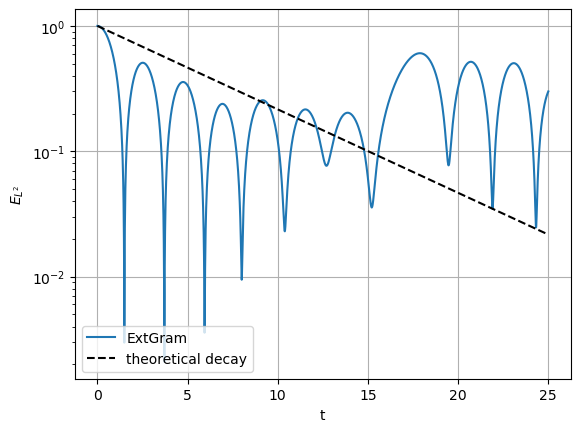

M=15, k=0.5


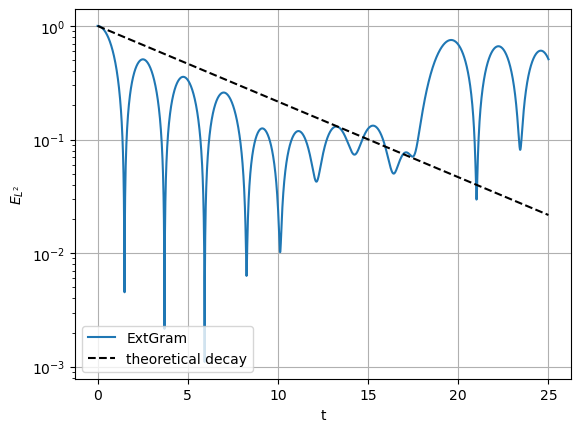

In [4]:
M_vec = [5, 7, 9, 11, 13, 15]
closures = ["ExtGram"]

for M in M_vec:
    print(f"M={M}, k={k}")

    plt.figure()
    for closure in closures:
        file = f"../out/VlasovPoisson/LandauDamping/energy_moments_closure{closure}_T{T_end}_M{M}_k{k}_ϵ{epsilon}_p{polydeg}_level{base_tree_level}_x_lower{x_lower}_x_upper{x_upper}.csv"
        data = pd.read_csv(file)

        plt.plot(data["time"], data["E_L2"] / data["E_L2"][0], label=closure)

    plt.plot(data["time"], np.exp(gamma * data["time"]), 'k--', label="theoretical decay")
    plt.yscale("log")
    plt.xlabel("t")
    plt.ylabel("$E_{L^2}$")
    plt.legend(loc='lower left')
    plt.grid()
    plt.savefig(f"../out/VlasovPoisson/LandauDamping/LandauDamping_M{M}_k{k}_epsilon{epsilon}_p{polydeg}.pdf")
    plt.show()

## Recursion time

In [5]:
T_end = 25.0

base_tree_level = 6
polydeg = 3

epsilon = 0.01
k = 0.5

/tmp/ipykernel_17142/3839867979.py:45: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig_E.show()


Recursion times
----------------
M=4: t_rec=0.4280561699787613
M=6: t_rec=0.4416332722106563
M=8: t_rec=0.45
M=10: t_rec=0.4938542614509653
M=12: t_rec=0.4888709174081624


/tmp/ipykernel_17142/3839867979.py:45: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig_E.show()


Recursion times
----------------
M=4: t_rec=0.4395213362765961
M=6: t_rec=0.4818587434740347
M=8: t_rec=0.4909128061741966
M=10: t_rec=0.5741565037556026
M=12: t_rec=0.5718810541206856


/tmp/ipykernel_17142/3839867979.py:45: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig_E.show()
/tmp/ipykernel_17142/3839867979.py:61: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig_recursion.show()


Recursion times
----------------
M=4: t_rec=0.45
M=6: t_rec=0.4887499651369306
M=8: t_rec=0.5714657525324346
M=10: t_rec=0.7873015180048468
M=12: t_rec=0.8083408035106295


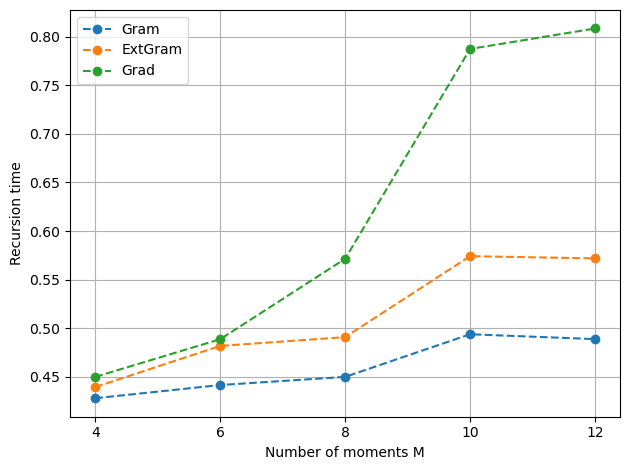

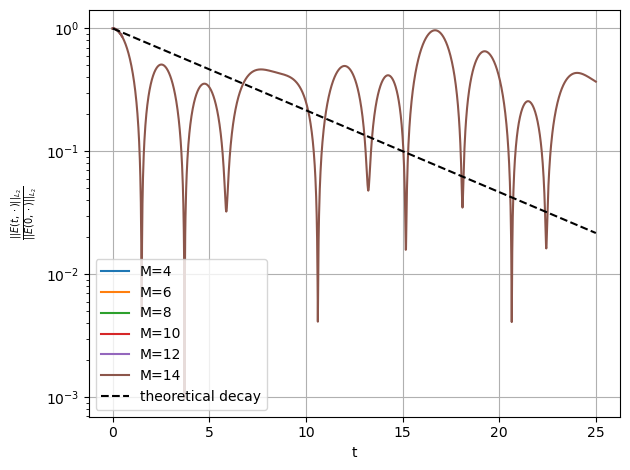

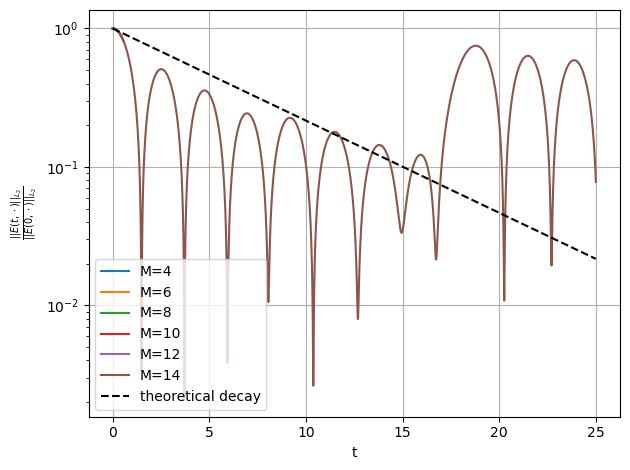

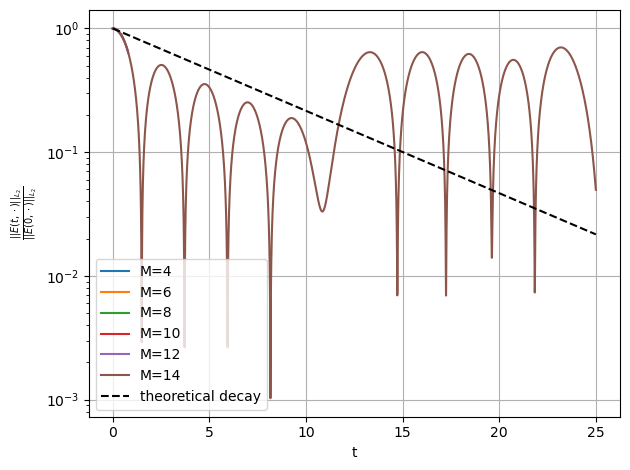

In [6]:
# Even Order Moments
closures = [
    "Gram",
    "ExtGram",
    "Grad"
]
M_vec = [4, 6, 8, 10, 12, 14]

# recursion time
rel_tol = 0.1
# reference solution
file = f"../out/VlasovPoisson/LandauDamping/energy_moments_closureExtGram_T{T_end}_M{24}_k{k}_ϵ{epsilon}_p{polydeg}_level{base_tree_level}_x_lower{x_lower}_x_upper{x_upper}.csv"
data = pd.read_csv(file)
E_ref = data["E_L2"].to_numpy() / data["E_L2"][0]

fig_recursion, ax_recursion = plt.subplots()
for closure in closures:
    recursion_time = []
    fig_E, ax_E = plt.subplots()
    for M in M_vec:

        file = f"../out/VlasovPoisson/LandauDamping/energy_moments_closure{closure}_T{T_end}_M{M}_k{k}_ϵ{epsilon}_p{polydeg}_level{base_tree_level}_x_lower{x_lower}_x_upper{x_upper}.csv"
        data = pd.read_csv(file)
        # plt.plot(data["time"], data["E_L2"] / data["E_L2"][0], label=f'M={M}')

        # recursion time: time until which the solution is accurate
        if M != M_vec[-1]:
            E_num = data["E_L2"].to_numpy() / data["E_L2"][0]
            for t_idx in range(len(E_num)):
                if (E_ref[t_idx] - E_num[t_idx]) * np.exp(-gamma * data["time"][t_idx]) > rel_tol:
                    recursion_time.append(data["time"][t_idx])
                    ax_E.plot(data["time"][:4//3*t_idx], data["E_L2"][:4//3*t_idx] / data["E_L2"][0], label=f'M={M}')
                    break
        else:
            ax_E.plot(data["time"], data["E_L2"] / data["E_L2"][0], label=f'M={M}')
            ax_E.plot(data["time"], np.exp(gamma * data["time"]), "k--", label="theoretical decay")
    ax_E.set_yscale("log")
    ax_E.set_xlabel("t")
    ax_E.set_ylabel("$\\frac{||E(t,\cdot)||_{L_2}}{||E(0,\cdot)||_{L_2}}$")
    # ax_E.set_title(closure)
    ax_E.legend(loc='lower left')
    ax_E.grid()
    fig_E.savefig(f"../out/VlasovPoisson/LandauDamping/LandauDamping_Even_Closure{closure}_k{k}_epsilon{epsilon}_p{polydeg}.pdf")
    fig_E.tight_layout()
    fig_E.show()

    print("Recursion times")
    print("----------------")
    for i, M in enumerate(M_vec[:-1]):
        print(f"M={M}: t_rec={recursion_time[i]}")

    ax_recursion.plot(M_vec[:-1], recursion_time, "o--", label=f"{closure}")
ax_recursion.set_xlabel("Number of moments M")
ax_recursion.set_ylabel("Recursion time")
ax_recursion.set_xticks(M_vec[:-1])
# ax_recursion.set_title(f"k={k}")
ax_recursion.legend()
ax_recursion.grid()
fig_recursion.savefig(f"../out/VlasovPoisson/LandauDamping_RecursionTime_Even_k{k}_epsilon{epsilon}_p{polydeg}.pdf")
fig_recursion.tight_layout()
fig_recursion.show()

Recursion times
----------------
M=5: t_rec=0.4830328183030389
M=7: t_rec=0.4921289663970193
M=9: t_rec=0.5747636438069551
M=11: t_rec=0.5723579341949222
M=13: t_rec=0.5705150096843282


/tmp/ipykernel_17142/340044136.py:33: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig_E.show()
/tmp/ipykernel_17142/340044136.py:49: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig_recursion.show()


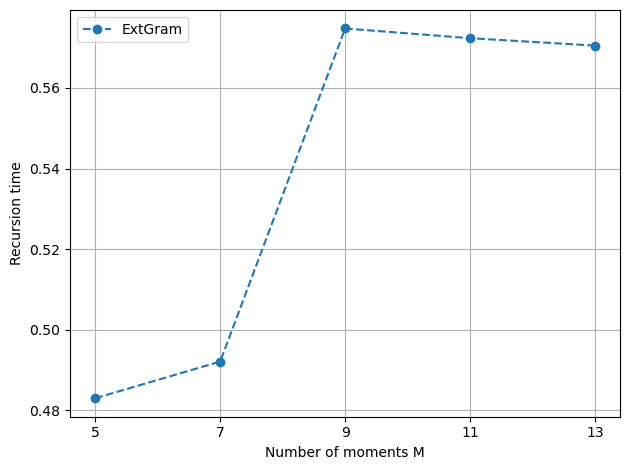

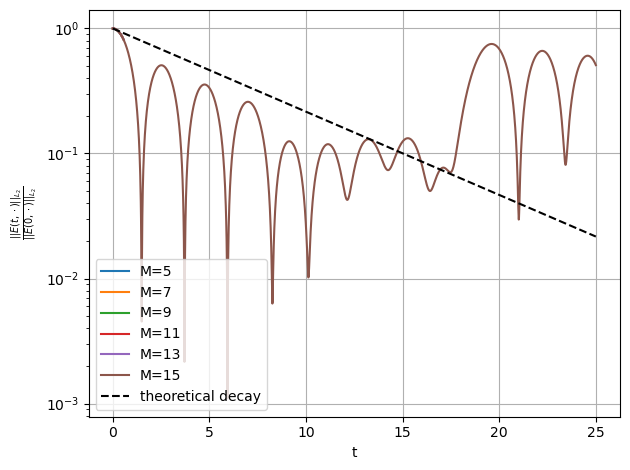

In [7]:
M_vec = [5, 7, 9, 11, 13, 15]
closures = ["ExtGram"]

fig_recursion, ax_recursion = plt.subplots()
for closure in closures:
    recursion_time = []
    fig_E, ax_E = plt.subplots()
    for M in M_vec:

        file = f"../out/VlasovPoisson/LandauDamping/energy_moments_closure{closure}_T{T_end}_M{M}_k{k}_ϵ{epsilon}_p{polydeg}_level{base_tree_level}_x_lower{x_lower}_x_upper{x_upper}.csv"
        data = pd.read_csv(file)
        # plt.plot(data["time"], data["E_L2"] / data["E_L2"][0], label=f'M={M}')

        # recursion time: time until which the solution is accurate
        if M != M_vec[-1]:
            E_num = data["E_L2"].to_numpy() / data["E_L2"][0]
            for t_idx in range(len(E_num)):
                if (E_ref[t_idx] - E_num[t_idx]) * np.exp(-gamma * data["time"][t_idx]) > rel_tol:
                    recursion_time.append(data["time"][t_idx])
                    ax_E.plot(data["time"][:4//3*t_idx], data["E_L2"][:4//3*t_idx] / data["E_L2"][0], label=f'M={M}')
                    break
        else:
            ax_E.plot(data["time"], data["E_L2"] / data["E_L2"][0], label=f'M={M}')
            ax_E.plot(data["time"], np.exp(gamma * data["time"]), "k--", label="theoretical decay")
    ax_E.set_yscale("log")
    ax_E.set_xlabel("t")
    ax_E.set_ylabel("$\\frac{||E(t,\cdot)||_{L_2}}{||E(0,\cdot)||_{L_2}}$")
    # ax_E.set_title(closure)
    ax_E.legend(loc='lower left')
    ax_E.grid()
    fig_E.savefig(f"../out/VlasovPoisson/LandauDamping/LandauDamping_Even_Closure{closure}_k{k}_epsilon{epsilon}_p{polydeg}.pdf")
    fig_E.tight_layout()
    fig_E.show()

    print("Recursion times")
    print("----------------")
    for i, M in enumerate(M_vec[:-1]):
        print(f"M={M}: t_rec={recursion_time[i]}")

    ax_recursion.plot(M_vec[:-1], recursion_time, "o--", label=f"{closure}")
ax_recursion.set_xlabel("Number of moments M")
ax_recursion.set_ylabel("Recursion time")
ax_recursion.set_xticks(M_vec[:-1])
# ax_recursion.set_title(f"k={k}")
ax_recursion.legend()
ax_recursion.grid()
fig_recursion.savefig(f"../out/VlasovPoisson/LandauDamping_RecursionTime_Even_k{k}_epsilon{epsilon}_p{polydeg}.pdf")
fig_recursion.tight_layout()
fig_recursion.show()

# Two-stream instability

In [8]:
def get_E_num(closure, T_end, M, k_, epsilon, polydeg, base_tree_level):
    file = f"../out/VlasovPoisson/TwoStreamInstability/energy_moments_closure{closure}_T{T_end}_M{M}_k{k_}_ϵ{epsilon}_p{polydeg}_level{base_tree_level}.csv"
    data = pd.read_csv(file)

    return data

Closure: Gram


/tmp/ipykernel_17142/194835208.py:25: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


Closure: ExtGram


/tmp/ipykernel_17142/194835208.py:25: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


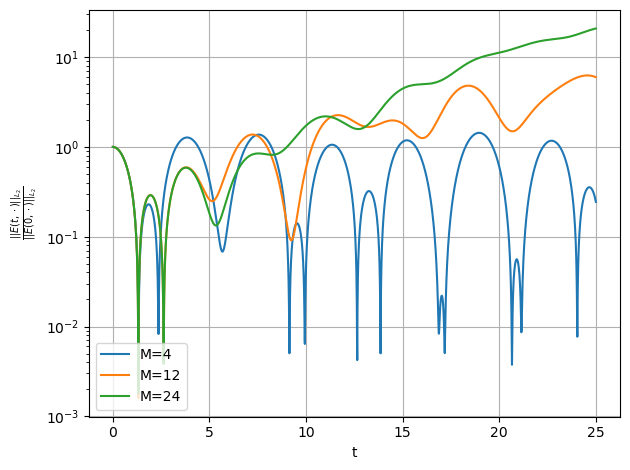

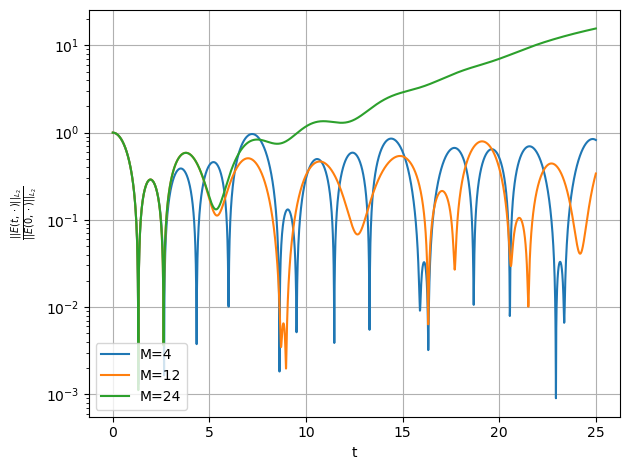

In [9]:
T_end = 25
base_tree_level = 8
polydeg = 1

# Even Order Moments

closures =[
    "Gram",
    "ExtGram"
]
for closure in closures:
    print(f"Closure: {closure}")
    fig, ax = plt.subplots()
    for M in [4, 12, 24]:
        data = get_E_num(closure, T_end, M, k, epsilon, polydeg, base_tree_level)
        ax.plot(data["time"], data["E_L2"] / data["E_L2"][0], label=f'M={M}')
    ax.set_yscale("log")
    ax.set_xlabel("t")
    ax.set_ylabel("$\\frac{||E(t,\cdot)||_{L_2}}{||E(0,\cdot)||_{L_2}}$")
    # ax.set_title(closure)
    ax.legend(loc='lower left')
    ax.grid()
    fig.savefig(f"../out/VlasovPoisson/TwoStreamInstability/TwoStreamInstability_Even_Closure{closure}_k{k}_epsilon{epsilon}_p{polydeg}.pdf")
    fig.tight_layout()
    fig.show()

In [10]:
T_end = 25.0 # different timing on clusterruns # todo: fix this

Closure: ExtGram


/tmp/ipykernel_17142/3726024996.py:21: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


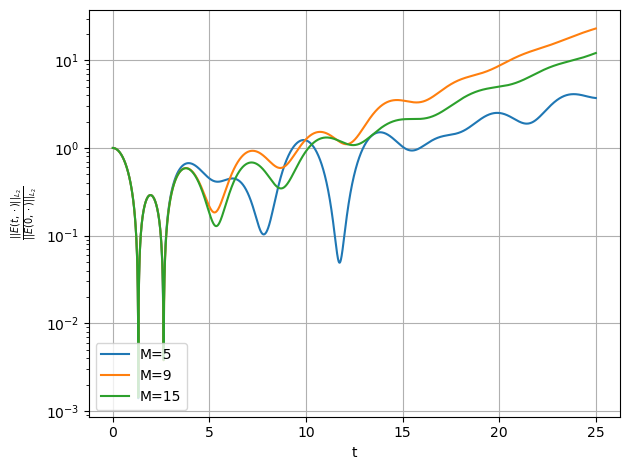

In [11]:
polydeg = 1

closures =[
    # "Gram",
    "ExtGram"
]
for closure in closures:
    print(f"Closure: {closure}")
    fig, ax = plt.subplots()
    for M in [5, 9, 15]: # todo 25 just running -> include, 25]:
        data = get_E_num(closure, T_end, M, k, epsilon, polydeg, base_tree_level)
        ax.plot(data["time"], data["E_L2"] / data["E_L2"][0], label=f'M={M}')
    ax.set_yscale("log")
    ax.set_xlabel("t")
    ax.set_ylabel("$\\frac{||E(t,\cdot)||_{L_2}}{||E(0,\cdot)||_{L_2}}$")
    # ax.set_title(closure)
    ax.legend(loc='lower left')
    ax.grid()
    fig.savefig(f"../out/VlasovPoisson/TwoStreamInstability/TwoStreamInstability_Even_Closure{closure}_k{k}_epsilon{epsilon}_p{polydeg}.pdf")
    fig.tight_layout()
    fig.show()

Closure: ExtGram


/tmp/ipykernel_17142/3890297295.py:23: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


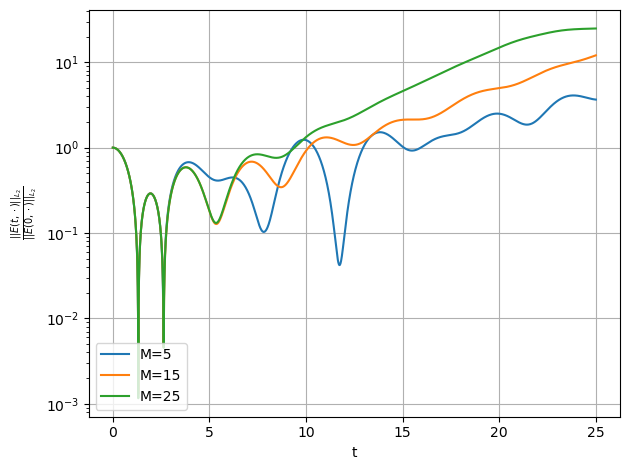

In [15]:
T_end = 25 # different timing on clusterruns # todo: fix this
base_tree_level = 6
polydeg = 3

closures =[
    # "Gram",
    "ExtGram"
]
for closure in closures:
    print(f"Closure: {closure}")
    fig, ax = plt.subplots()
    for M in [5, 15, 25]: # todo 25 just running -> include, 25]:
        data = get_E_num(closure, T_end, M, k, epsilon, polydeg, base_tree_level)
        ax.plot(data["time"], data["E_L2"] / data["E_L2"][0], label=f'M={M}')
    ax.set_yscale("log")
    ax.set_xlabel("t")
    ax.set_ylabel("$\\frac{||E(t,\cdot)||_{L_2}}{||E(0,\cdot)||_{L_2}}$")
    # ax.set_title(closure)
    ax.legend(loc='lower left')
    ax.grid()
    fig.savefig(f"../out/VlasovPoisson/TwoStreamInstability/TwoStreamInstability_Even_Closure{closure}_k{k}_epsilon{epsilon}_p{polydeg}.pdf")
    fig.tight_layout()
    fig.show()